In [5]:
%pylab inline
import pandas as pd

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [6]:
def read_merged(path="../z30"):
    from pathlib import Path
    path = Path(path)
    df = pd.read_csv(path / "AssociatedResults/sim_merged.csv" )
    df["ev/Δx"] = ((df["ev/x"]-255/2)*120/256)- df["sim/px"]
    df["px/Δx"] = ((df["px/x"]-255/2)*120/256)- df["sim/px"]
    df["ph/Δx"] = ((df["ph/x"]-255/2)*120/256)- df["sim/px"]
    
    df["ev/Δtoa"] = df["ev/toa"]- df["sim/toa"]*1e-9
    df["px/Δtoa"] = df["px/toa"]- df["sim/toa"]*1e-9
    df["ph/Δtoa"] = df["ph/toa"]- df["sim/toa"]*1e-9
    
    df["ev/n"] = df.groupby("ev/id")["ph/id"].transform("nunique")
    df["ph/n"] = df.groupby("ph/id")["px/id"].transform("nunique")

    df["dz"] = pd.cut(df["sim/pz"],arange(0,21,1),labels=arange(0,20,1))

    df.name = path.stem
    return df

In [13]:
# oof = read_merged("archive/openbeam_ptb_5e6/out_of_focus/")

inf = read_merged("archive/openbeam_ptb_1e4/znew/zscan_12/")

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

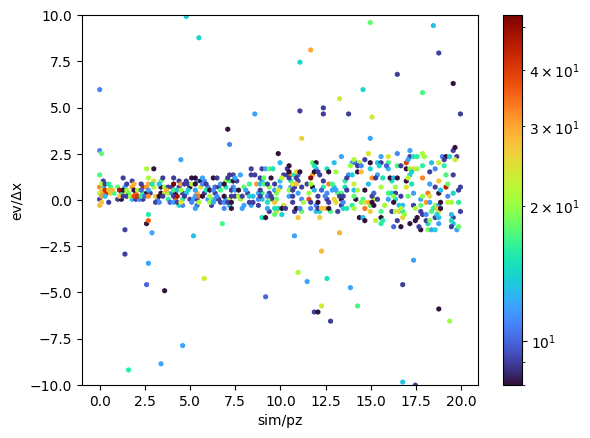

In [14]:
inf.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500),cmap="turbo")

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

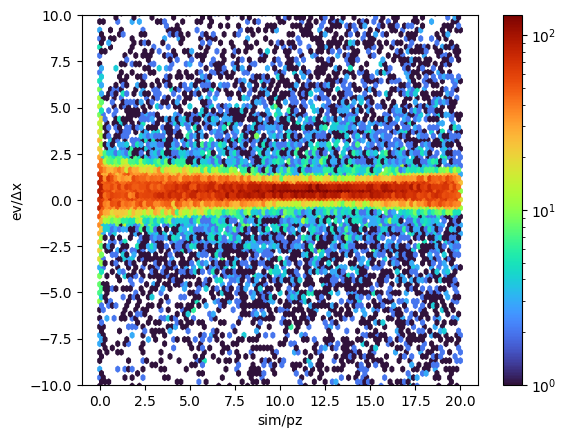

In [10]:
oof.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500),cmap="turbo")

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

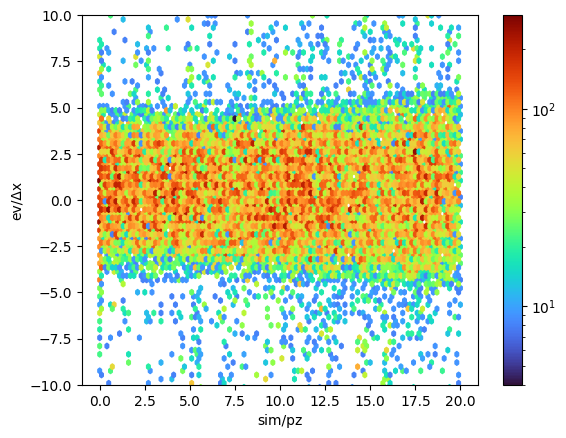

In [33]:
inf.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500),cmap="turbo")

<Axes: ylabel='Frequency'>

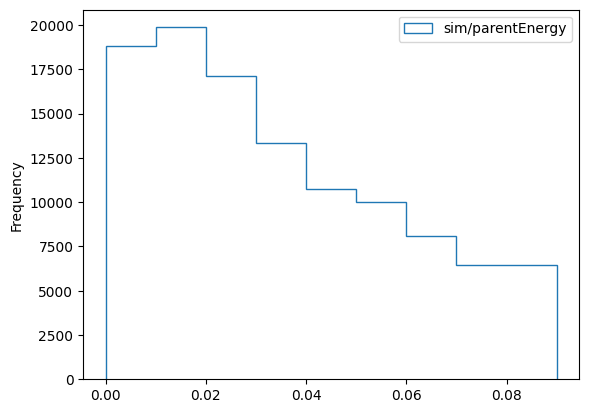

In [15]:
inf.plot.hist(y="sim/parentEnergy",bins=arange(0,0.1,0.01),histtype="step")

<Axes: xlabel='sim/parentEnergy', ylabel='sim/neutronEnergy'>

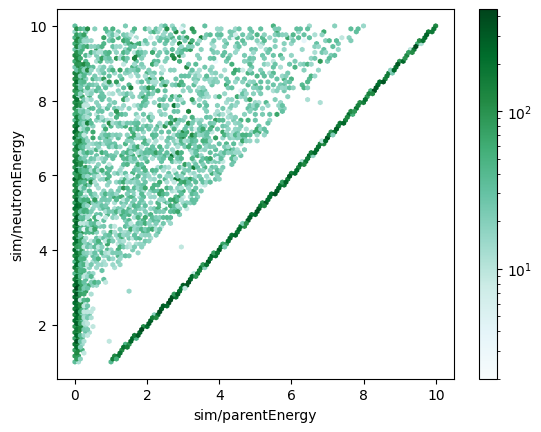

In [13]:
inf.query("`sim/pz`>0").plot.hexbin(x="sim/parentEnergy",y="sim/neutronEnergy",bins="log")#,ylim=(-10,10),gridsize=(100,500))

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

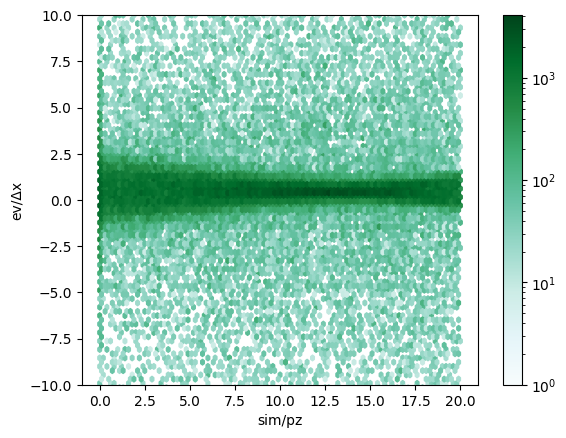

In [5]:
inf.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500))

<Axes: xlabel='sim/parentEnergy', ylabel='ev/Δx'>

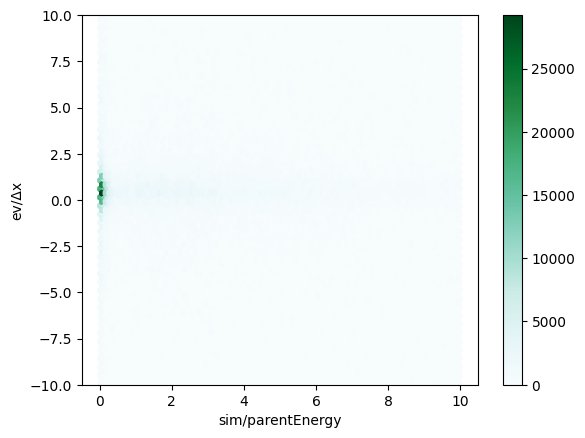

In [52]:
oof.plot.hexbin(x="sim/parentEnergy",y="ev/Δx",ylim=(-10,10),gridsize=(100,500))

/tmp/ipykernel_1188206/1901637401.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oof.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())
/tmp/ipykernel_1188206/1901637401.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())


<Axes: xlabel='dz'>

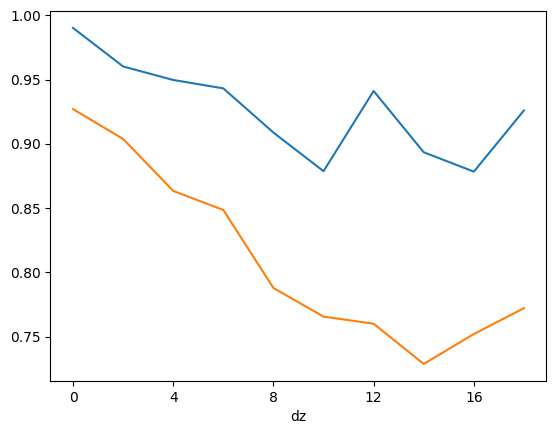

In [16]:
oof["dz"] = pd.cut(oof["sim/pz"],arange(0,21,2),labels=arange(0,20,2))
inf["dz"] = pd.cut(inf["sim/pz"],arange(0,21,2),labels=arange(0,20,2))
oof.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())
inf.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())

/tmp/ipykernel_1188206/2758074923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
in     Axes(0.125,0.11;0.775x0.77)
out    Axes(0.125,0.11;0.775x0.77)
dtype: object

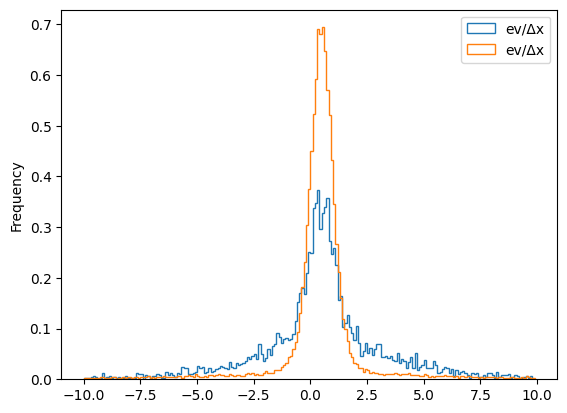

In [19]:
oof["dz"] = pd.cut(oof["sim/nz"],[-20000,-3000,2000],labels=["in","out"])
oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

In [27]:
inf.dropna()

,px/id,sim/toa2,sim/toa_tick,sim/id,sim/neutron_id,sim/pulse_id,sim/pulse_time_ns,sim/wavelength,sim/parentName,sim/parentEnergy,...,ev/n,ev/psd,ev/Δx,px/Δx,ph/Δx,ev/Δtoa,px/Δtoa,ph/Δtoa,ph/n,dz
38,38,6.841281e+06,4378420.0,11730.0,4673.0,6842.0,6841000.0,453.86,e-,1.0828,...,1.0,0.0,-0.238579,0.463425,-0.238579,6.165426e-10,2.092904e-08,6.165426e-10,20.0,in
296,296,7.011233e+08,448718939.0,7415.0,479236.0,701124.0,701123000.0,427.81,proton,6.0453,...,1.0,0.0,-6.026369,-6.499025,-6.026369,2.461074e-09,1.964857e-08,2.461074e-09,14.0,out
591,592,7.012695e+08,448812488.0,1702.0,479339.0,701270.0,701269000.0,416.21,proton,0.2526,...,1.0,0.0,0.147343,0.898975,0.147343,-2.011189e-09,4.017631e-08,-2.011189e-09,22.0,out
992,992,7.014213e+08,448909655.0,592.0,479451.0,701422.0,701421000.0,442.58,proton,0.0097,...,1.0,0.0,0.119898,0.361025,0.119898,-2.163604e-09,3.689890e-08,-2.163604e-09,12.0,out
1069,1069,7.014703e+08,448941013.0,8280.0,479484.0,701471.0,701470000.0,425.53,e-,0.7451,...,1.0,0.0,-2.297455,-2.529925,-2.297455,1.515667e-09,7.765667e-09,1.515667e-09,9.0,in
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7511046,7511046,6.554662e+07,41949840.0,222.0,44620.0,65547.0,65546000.0,431.25,proton,1.6750,...,1.0,0.0,0.774899,0.298825,0.774899,4.378312e-09,1.531581e-08,4.378312e-09,9.0,out
7511213,7511213,6.561662e+07,41994638.0,103.0,44671.0,65617.0,65616000.0,449.20,proton,0.0070,...,1.0,0.0,1.041967,1.038125,1.041967,4.261443e-09,4.261443e-09,4.261443e-09,9.0,out
7511614,7511614,6.576030e+07,42086593.0,1602.0,44775.0,65760.0,65760000.0,471.98,proton,8.5948,...,1.0,0.0,0.656231,-0.042225,0.656231,4.069096e-09,3.063160e-08,4.069096e-09,14.0,out
7511615,7511615,6.576031e+07,42086597.0,1602.0,44775.0,65760.0,65760000.0,471.98,proton,8.5948,...,1.0,0.0,0.656231,-0.042225,0.656231,4.069096e-09,3.688160e-08,4.069096e-09,14.0,out


In [24]:
oof.groupby(["sim/nz","sim/parentName"])["ev/Δx"].count().unstack()

sim/parentName,Be9,C12,C13,alpha,deuteron,e+,e-,proton
sim/nz,,,,,,,,
-10850.0000,NaN,55.0,NaN,NaN,NaN,242.0,4354.0,1879.0
0.0005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
0.0009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
0.0017,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.0
0.0031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...
19.9960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
19.9986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
19.9989,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0


In [22]:
oof["sim/nz"].value_counts()

sim/nz
-10850.0000    6726
 11.2715          7
 3.9834           7
 18.0336          6
 0.8707           6
               ... 
 2.1466           1
 4.6449           1
 6.8723           1
 8.9389           1
 5.6371           1
Name: count, Length: 42111, dtype: int64

/tmp/ipykernel_1188206/4192545627.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
in     Axes(0.125,0.11;0.775x0.77)
out    Axes(0.125,0.11;0.775x0.77)
dtype: object

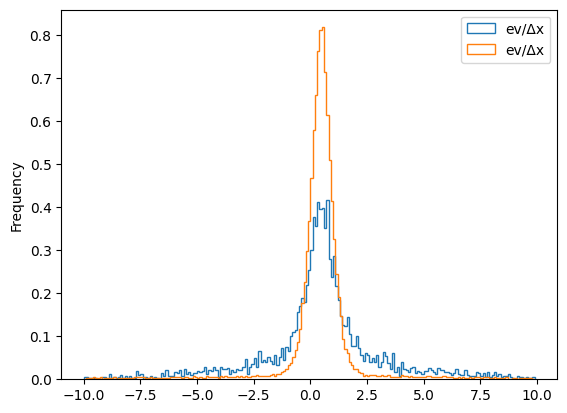

In [20]:
inf["dz"] = pd.cut(inf["sim/nz"],[-20000,-3000,2000],labels=["in","out"])
inf.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

/tmp/ipykernel_1188206/1481696765.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
0     Axes(0.125,0.11;0.775x0.77)
10    Axes(0.125,0.11;0.775x0.77)
dtype: object

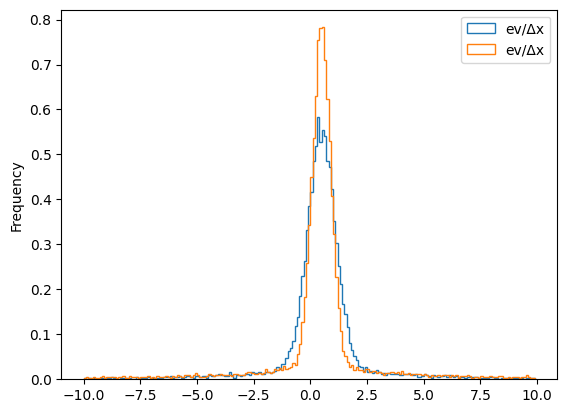

In [17]:
oof["dz"] = pd.cut(oof["sim/pz"],arange(0,21,10),labels=arange(0,20,10))
oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

/tmp/ipykernel_149774/1193086978.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.groupby("dE").plot.hist(y="ph/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=True,density=True)


dE
0.00    Axes(0.125,0.11;0.775x0.77)
0.02    Axes(0.125,0.11;0.775x0.77)
0.10    Axes(0.125,0.11;0.775x0.77)
1.00    Axes(0.125,0.11;0.775x0.77)
5.00    Axes(0.125,0.11;0.775x0.77)
dtype: object

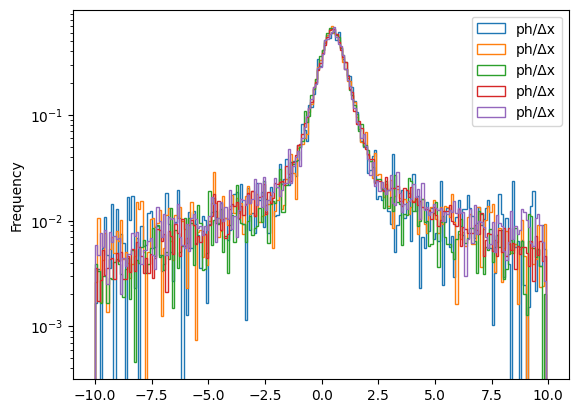

In [49]:
ebins = [0,0.02,0.1,1,5,10]
inf["dE"] = pd.cut(inf["sim/parentEnergy"],ebins,labels=ebins[:-1])
inf.groupby("dE").plot.hist(y="ph/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=True,density=True)

/tmp/ipykernel_1573091/3829202157.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
0     Axes(0.125,0.11;0.775x0.77)
10    Axes(0.125,0.11;0.775x0.77)
dtype: object

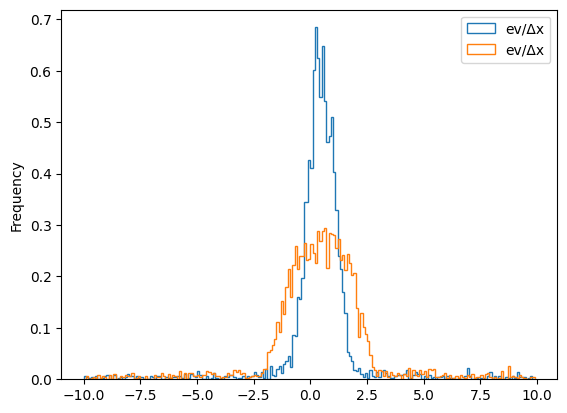

In [14]:
inf["dz"] = pd.cut(inf["sim/pz"],arange(0,21,10),labels=arange(0,20,10))
inf.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

In [40]:
oof.query("`sim/parentEnergy`<0.1").groupby("sim/parentName")["sim/nz"].describe()

,count,mean,std,min,25%,50%,75%,max
sim/parentName,,,,,,,,
e-,363.0,-10850.000000,0.000000,-10850.0,-10850.0000,-10850.0000,-10850.0000,-10850.0000
proton,330788.0,-684.603022,2658.783245,-10850.0,4.2809,10.5425,16.0461,19.9986


In [15]:
inf.groupby("sim/parentName")["sim/nz"].describe()

,count,mean,std,min,25%,50%,75%,max
sim/parentName,,,,,,,,
Be9,138.0,8.724517,5.582150e+00,0.3492,2.9818,7.3302,13.7550,17.1384
C12,3695.0,-0.797680,2.251530e+01,-90.9665,1.0145,6.7758,12.3182,19.9852
C13,27.0,4.632033,1.895065e+00,2.0052,2.0052,5.8350,6.0559,6.0559
alpha,99.0,10.078091,3.516321e+00,4.9973,6.5978,10.6979,12.8602,15.9440
deuteron,15.0,7.126800,9.193520e-16,7.1268,7.1268,7.1268,7.1268,7.1268
e+,594.0,-29.981337,3.461153e+01,-88.9336,-63.5084,-34.9707,13.0242,15.4202
e-,11442.0,-40.029186,3.322968e+01,-94.5420,-65.7339,-40.2207,-20.9718,19.3408
proton,94300.0,4.318300,2.013231e+01,-95.0779,3.3123,9.5965,15.4156,19.9969


In [122]:
oof.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230508 entries, 0 to 230507
Data columns (total 46 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   px/id              230508 non-null  int64   
 1   sim/toa2           230466 non-null  float64 
 2   sim/toa_tick       230466 non-null  float64 
 3   sim/id             230466 non-null  float64 
 4   sim/neutron_id     230466 non-null  float64 
 5   sim/pulse_id       230466 non-null  float64 
 6   sim/pulse_time_ns  230466 non-null  float64 
 7   sim/wavelength     230466 non-null  float64 
 8   sim/parentName     230466 non-null  object  
 9   sim/parentEnergy   230466 non-null  float64 
 10  sim/neutronEnergy  230466 non-null  float64 
 11  sim/x              230466 non-null  float64 
 12  sim/y              230466 non-null  float64 
 13  sim/z              230466 non-null  float64 
 14  sim/toa            230466 non-null  float64 
 15  sim/px             230466 non-null

In [124]:
inf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230508 entries, 0 to 230507
Data columns (total 46 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   px/id              230508 non-null  int64   
 1   sim/toa2           230466 non-null  float64 
 2   sim/toa_tick       230466 non-null  float64 
 3   sim/id             230466 non-null  float64 
 4   sim/neutron_id     230466 non-null  float64 
 5   sim/pulse_id       230466 non-null  float64 
 6   sim/pulse_time_ns  230466 non-null  float64 
 7   sim/wavelength     230466 non-null  float64 
 8   sim/parentName     230466 non-null  object  
 9   sim/parentEnergy   230466 non-null  float64 
 10  sim/neutronEnergy  230466 non-null  float64 
 11  sim/x              230466 non-null  float64 
 12  sim/y              230466 non-null  float64 
 13  sim/z              230466 non-null  float64 
 14  sim/toa            230466 non-null  float64 
 15  sim/px             230466 non-null

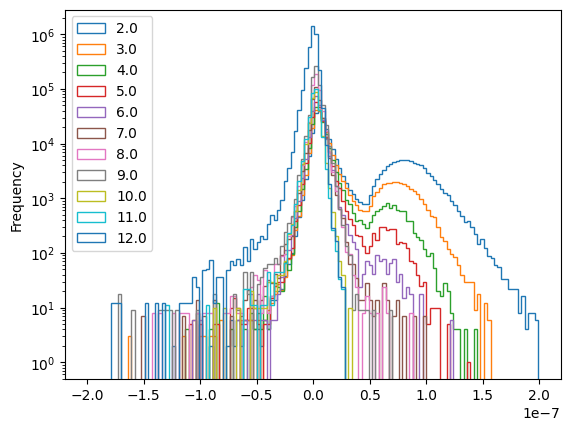

In [37]:
oof.query("-5e-7<`ev/Δtoa`<1e-7").groupby("ph/n")["ph/Δtoa"].plot.hist(bins=arange(-2e-7,2e-7,3e-9),histtype="step",logy=True,legend=True);

<Axes: xlabel='ph/n', ylabel='ph/Δtoa'>

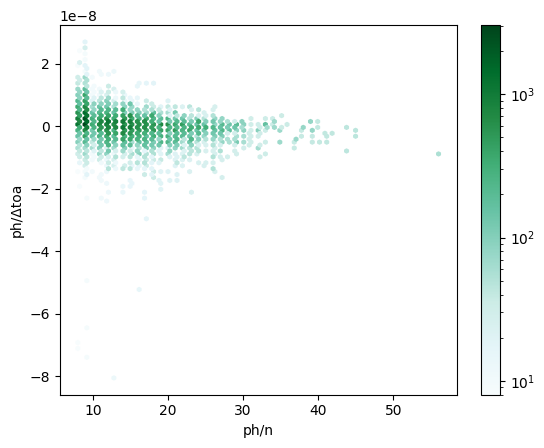

In [16]:
inf.query("-1e-7<`ev/Δtoa`<1e-7").plot.hexbin(x="ph/n",y="ph/Δtoa",bins="log")

<Axes: xlabel='px/tof', ylabel='ev/Δtoa'>

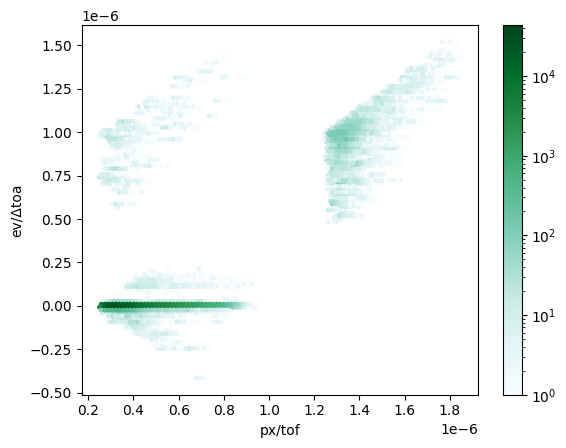

In [31]:
oof.query("-1e-6<`ev/Δtoa`<1e-5 and `px/tof`<3e-6").plot.hexbin(x="px/tof",y="ev/Δtoa",bins="log")

<Axes: xlabel='px/tof', ylabel='ev/Δtoa'>

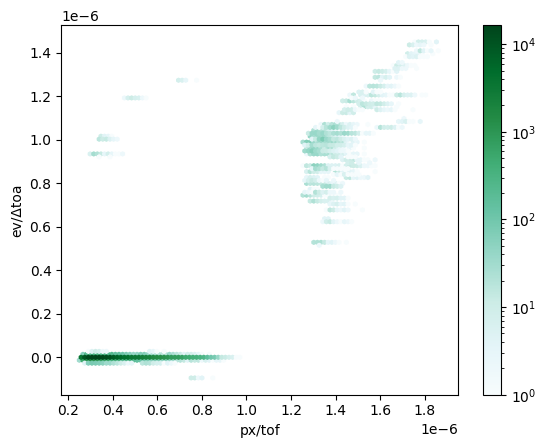

In [146]:
inf.query("-1e-6<`ev/Δtoa`<1e-4").plot.hexbin(x="px/tof",y="ev/Δtoa",bins="log")

<Axes: ylabel='Frequency'>

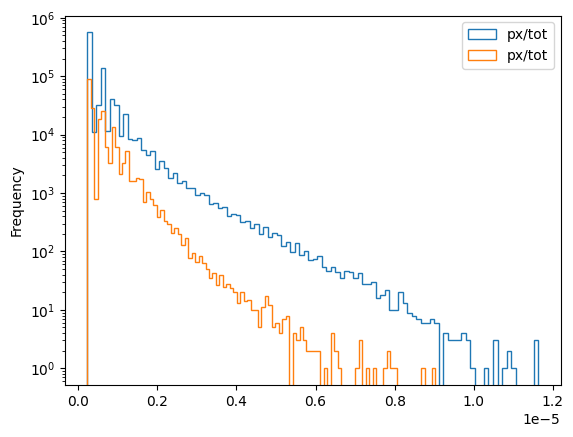

In [20]:
oof.dropna().plot.hist(y=["px/tot"],bins=100,histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["px/tot"],bins=100,histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

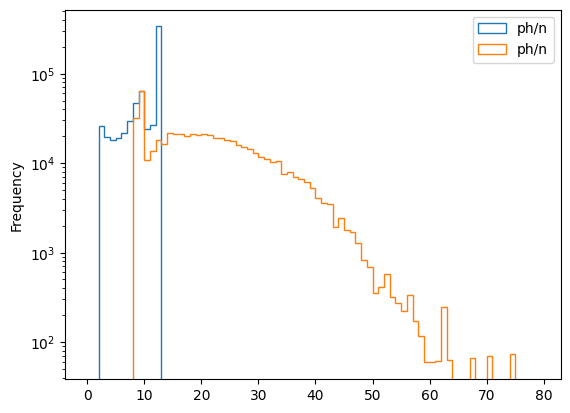

In [10]:
oof.dropna().plot.hist(y=["ph/n"],bins=arange(80),histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["ph/n"],bins=arange(80),histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

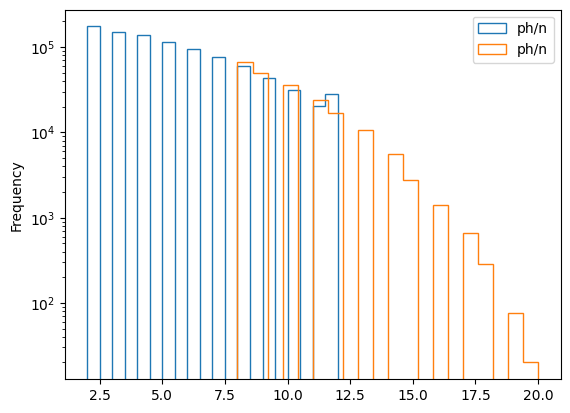

In [21]:
oof.dropna().plot.hist(y=["ph/n"],bins=20,histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["ph/n"],bins=20,histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

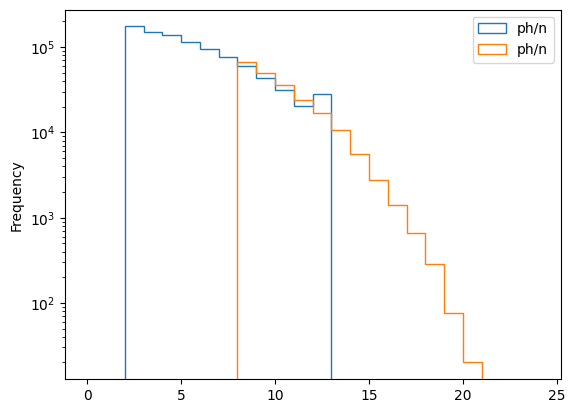

In [23]:
oof.dropna().plot.hist(y=["ph/n"],bins=arange(0,25,1),histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["ph/n"],bins=arange(0,25,1),histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

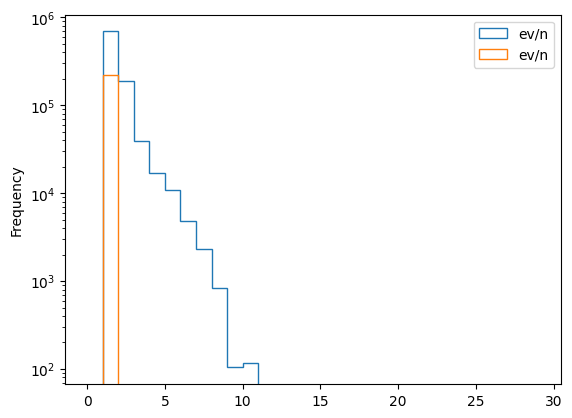

In [24]:
oof.plot.hist(y=["ev/n"],bins=arange(30),histtype="step",logy=True,ax=gca())
inf.plot.hist(y=["ev/n"],bins=arange(30),histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

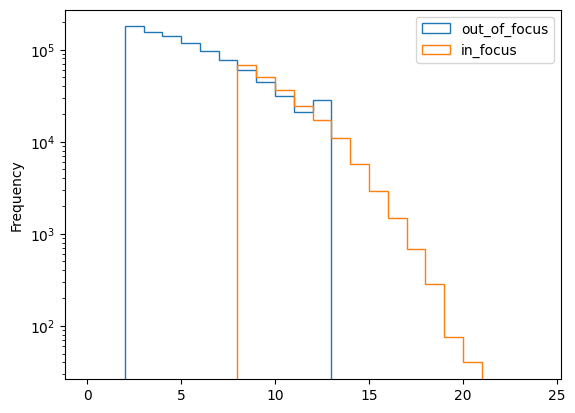

In [26]:
oof.plot.hist(y="ph/n",bins=arange(25),histtype="step",logy=True,ax=gca(),label=oof.name)
inf.plot.hist(y="ph/n",bins=arange(25),histtype="step",logy=True,ax=gca(),label=inf.name)

<Axes: ylabel='Frequency'>

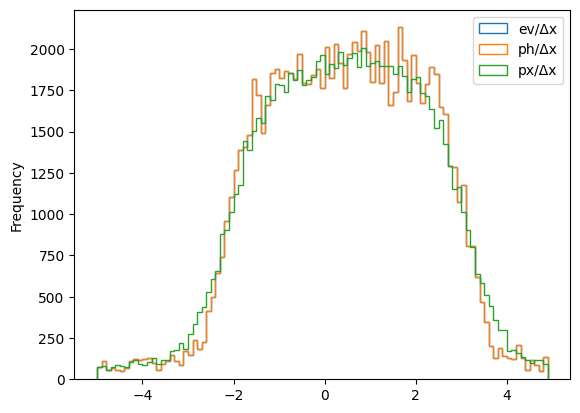

In [28]:
inf.query("`ph/n`<10").plot.hist(y=["ev/Δx","ph/Δx","px/Δx"],bins=arange(-5,5,0.1),histtype="step",logy=False)

In [12]:
df.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238571 entries, 0 to 238570
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   px/id              238571 non-null  int64  
 1   sim/toa2           238496 non-null  float64
 2   sim/toa_tick       238496 non-null  float64
 3   sim/id             238496 non-null  float64
 4   sim/neutron_id     238496 non-null  float64
 5   sim/pulse_id       238496 non-null  float64
 6   sim/pulse_time_ns  238496 non-null  float64
 7   sim/wavelength     238496 non-null  float64
 8   sim/parentName     238496 non-null  object 
 9   sim/parentEnergy   238496 non-null  float64
 10  sim/neutronEnergy  238496 non-null  float64
 11  sim/x              238496 non-null  float64
 12  sim/y              238496 non-null  float64
 13  sim/z              238496 non-null  float64
 14  sim/toa            238496 non-null  float64
 15  sim/px             238496 non-null  float64
 16  si

<Axes: ylabel='Frequency'>

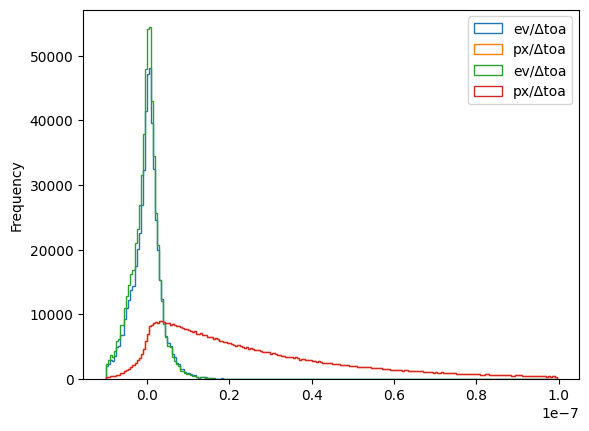

In [11]:
inf.plot.hist(y=["ev/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False)
oof.plot.hist(y=["ev/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False,ax=gca())

<Axes: ylabel='Frequency'>

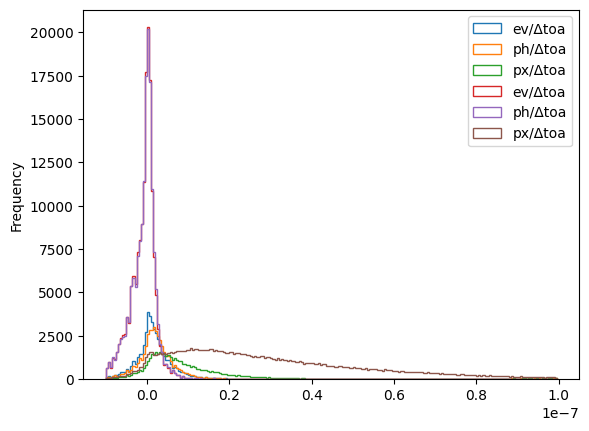

In [101]:
df.query("`ph/n`<10").plot.hist(y=["ev/Δtoa","ph/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False,ax=gca())
df.query("`ph/n`>10").plot.hist(y=["ev/Δtoa","ph/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False,ax=gca())

<Axes: ylabel='Frequency'>

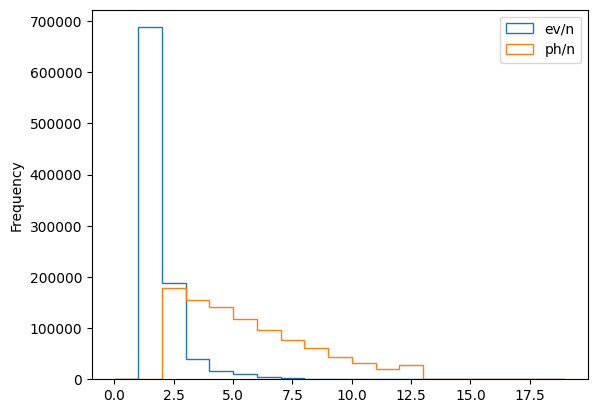

In [41]:
oof.plot.hist(y=["ev/n","ph/n"],bins=arange(20),histtype="step",logy=False)

<Axes: ylabel='Frequency'>

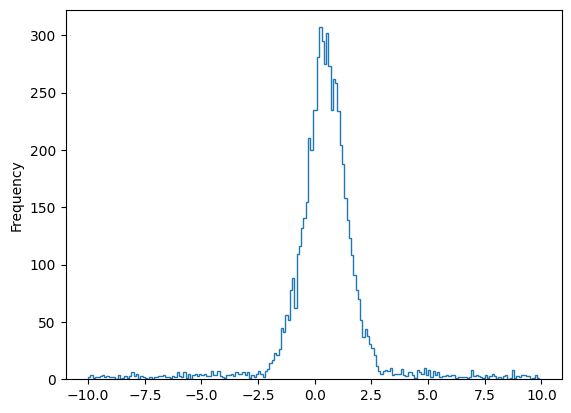

In [17]:
inf.groupby("ev/id")["ev/Δx"].mean().plot.hist(bins=arange(-10,10,0.1),histtype="step",logy=False)

<Axes: xlabel='px/x', ylabel='sim/nx'>

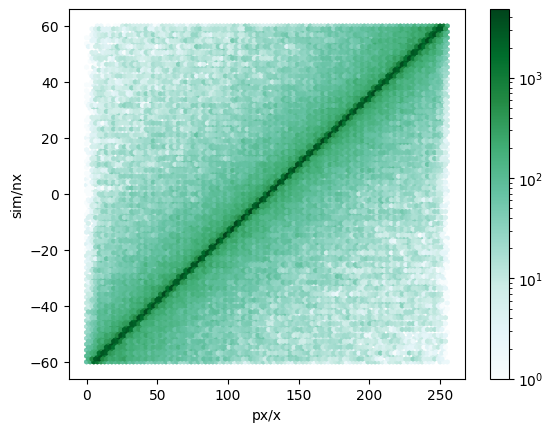

In [50]:
oof.plot.hexbin(x="px/x",y="sim/nx",bins="log")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7601171 entries, 0 to 469066
Data columns (total 25 columns):
 #   Column             Dtype  
---  ------             -----  
 0   px/id              int64  
 1   sim/toa2           float64
 2   sim/id             float64
 3   sim/neutron_id     float64
 4   sim/pulse_id       float64
 5   sim/pulse_time_ns  float64
 6   sim/wavelength     float64
 7   sim/parentName     object 
 8   sim/parentEnergy   float64
 9   sim/neutronEnergy  float64
 10  sim/x              float64
 11  sim/y              float64
 12  sim/z              float64
 13  sim/toa            float64
 14  ph/id              float64
 15  ev/id              float64
 16  ph/x               float64
 17  ph/y               float64
 18  ph/toa             float64
 19  ph/tof             float64
 20  ev/x               float64
 21  ev/y               float64
 22  ev/toa             float64
 23  ev/tof             float64
 24  ev/psd             float64
dtypes: float64(23), int64(1)

# distributions

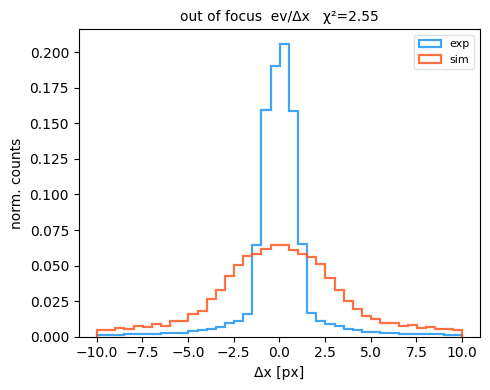

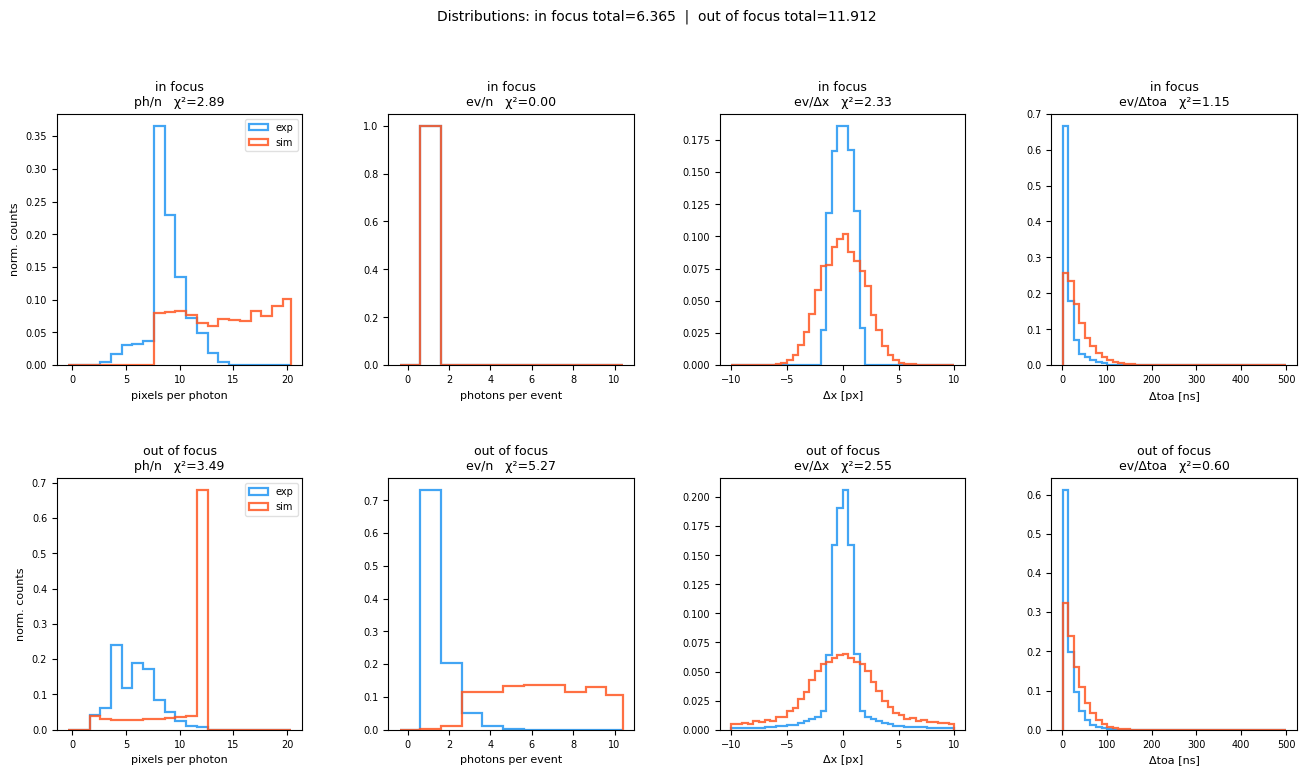

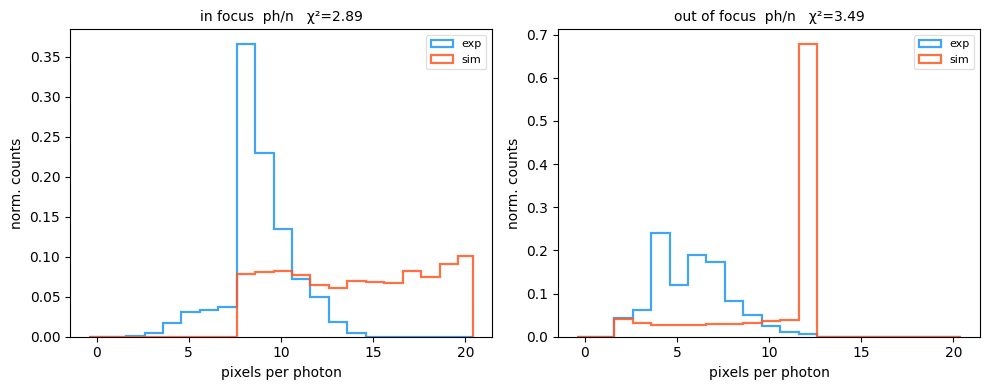

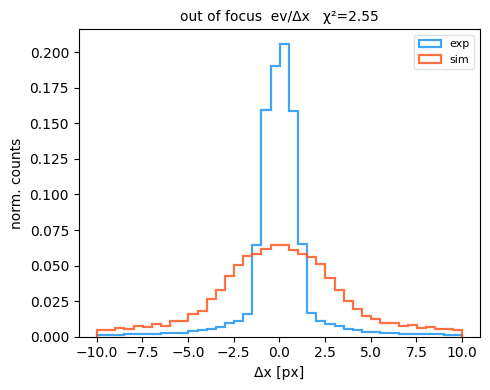

In [39]:
from empindex.plot import DistPlot

dp = DistPlot(inf="archive/openbeam_ptb/z/in_focus.json", 
              oof="archive/openbeam_ptb/z/out_of_focus.json")
# dp = DistPlot.from_val_dir("archive/openbeam_ptb_hs/z30")
dp.plot(kind="all")          # 2×4 grid
dp.plot(kind="ph/n")         # single panel, both rows
dp.plot(kind="ev_dx", focus="out_of_focus")




In [16]:
import json

with open("archive/openbeam_ptb/z/out_of_focus.json","r") as fid:
    oof = json.load(fid)

with open("lumacam_optimize/scan_archive_openbeam_ptb_z30_blob_gain/blob=1.0_gain=10000.0/in_focus.json","r") as fid:
    inf = json.load(fid)

In [17]:
oof['distributions_sim'].keys()

dict_keys(['ph_n', 'ev_n', 'ev_dx', 'ev_dtoa'])

In [18]:
oof.keys()

dict_keys(['sim_path', 'exp_path', 'limit_photons', 'distributions_sim', 'distributions_exp', 'scores', 'alpha', 'n_ph_ratio', 'scale_discrepancy'])

<Axes: >

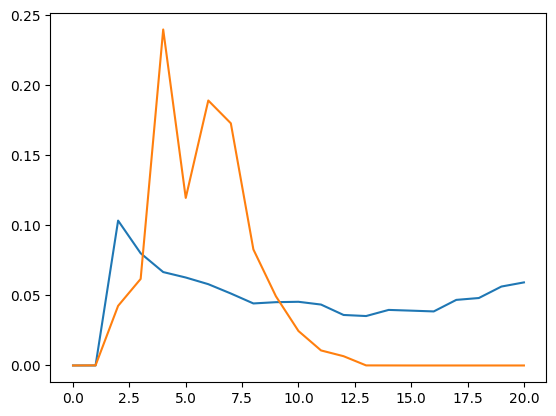

In [19]:
pd.Series(oof['distributions_sim']["ph_n"]).plot(ax=gca())
pd.Series(oof['distributions_exp']["ph_n"]).plot(ax=gca())

<Axes: >

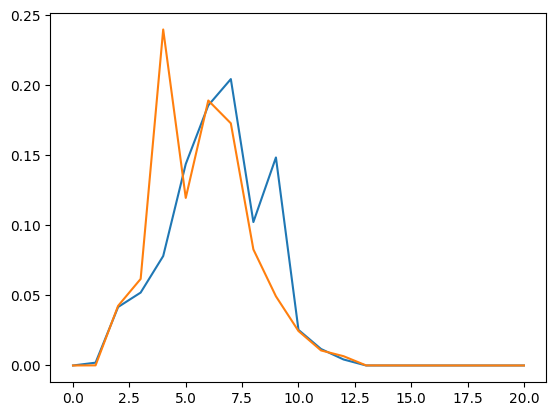

In [105]:
pd.Series(oof['distributions_sim']["ph_n"]).plot(ax=gca())
pd.Series(oof['distributions_exp']["ph_n"]).plot(ax=gca())

<Axes: >

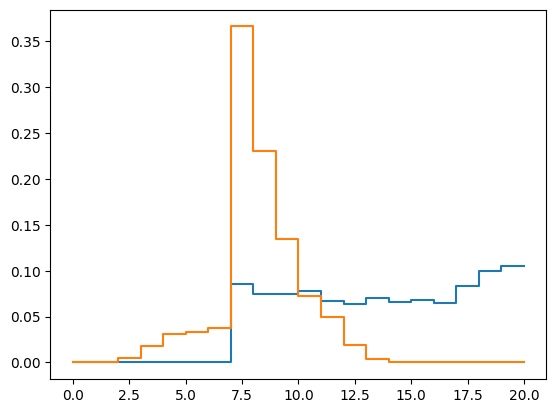

In [82]:
pd.Series(inf['distributions_sim']["ph_n"]).plot(ax=gca(),drawstyle="steps")
pd.Series(inf['distributions_exp']["ph_n"]).plot(ax=gca(),drawstyle="steps")

<Axes: >

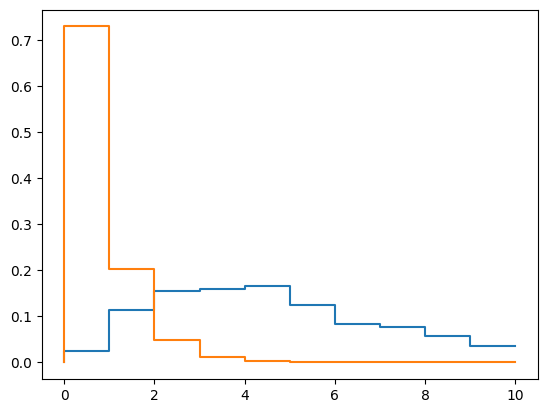

In [83]:
pd.Series(oof['distributions_sim']["ev_n"]).plot(ax=gca(),drawstyle="steps")
pd.Series(oof['distributions_exp']["ev_n"]).plot(ax=gca(),drawstyle="steps")

<Axes: >

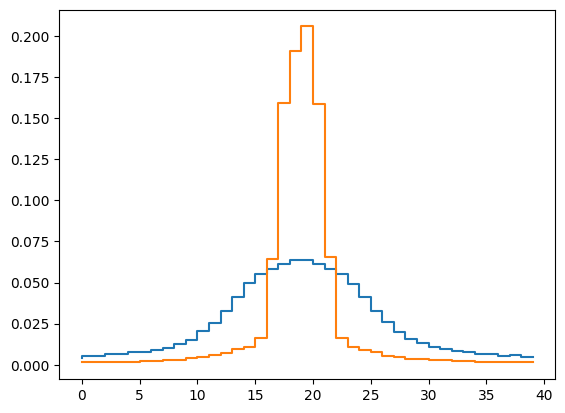

In [84]:
pd.Series(oof['distributions_sim']["ev_dx"]).plot(ax=gca(),drawstyle="steps")
pd.Series(oof['distributions_exp']["ev_dx"]).plot(ax=gca(),drawstyle="steps")

<Axes: >

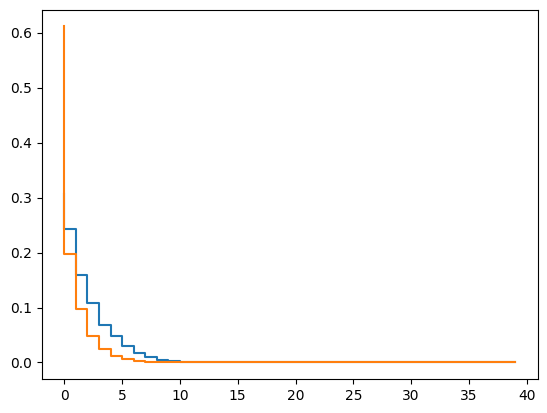

In [85]:
pd.Series(oof['distributions_sim']["ev_dtoa"]).plot(ax=gca(),drawstyle="steps")
pd.Series(oof['distributions_exp']["ev_dtoa"]).plot(ax=gca(),drawstyle="steps")

In [61]:
a = pd.read_json("lumacam_optimize/scan_archive_openbeam_ptb_z30_blob_gain/blob=1.0_gain=10000.0/out_of_focus.json")
a

,sim_path,exp_path,limit_photons,distributions_sim,distributions_exp,scores,alpha,n_ph_ratio,scale_discrepancy
ph_n,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.0, 0.0, 0.096332165670719, 0.07958994436431...","[0.0, 8.203580042330474e-05, 0.042551969679568...",2.133805,2.484968,5.803678,3.31871
ev_n,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.0, 0.024919668220696002, 0.1132820382798390...","[0.0, 0.7304341404273911, 0.20384680872014402,...",4.204292,2.484968,5.803678,3.31871
ev_dx,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.004328469595203, 0.005285776782727, 0.00543...","[0.0013519944622300002, 0.001427706152115, 0.0...",2.578268,2.484968,5.803678,3.31871
ev_dtoa,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.305593941738986, 0.24302599819431303, 0.159...","[0.611164662258609, 0.19716689363238102, 0.096...",0.684182,2.484968,5.803678,3.31871
total,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,NaN,NaN,9.600547,2.484968,5.803678,3.31871


In [59]:
a.set_index(["blob","gain"])["total_in"].unstack()

gain,5000.0,10000.0,15000.0
blob,,,
0.5,4.354188,4.314922,4.295794
1.0,6.345471,6.381577,6.369571
1.5,6.720207,6.791228,6.714671
2.0,6.908176,6.978680,6.972534


In [59]:
a.set_index(["blob","gain"])["total_in"].unstack()

gain,5000.0,10000.0,15000.0
blob,,,
0.5,4.354188,4.314922,4.295794
1.0,6.345471,6.381577,6.369571
1.5,6.720207,6.791228,6.714671
2.0,6.908176,6.978680,6.972534


# run lumacam

In [1]:
import lumacam

In [2]:
sim = lumacam.Simulate("archive/openbeam_ptb_1e4")

In [3]:
config = lumacam.Config.neutrons_tof()
config.sample_material = "G4Galactic"
config.freq = 1e6
config.num_events = 1e4
config

Configuration:
  Particle: neutron
  Energy: uniform distribution from 1.0 to 10.0 MeV
  (gradient: 0.0, intercept: 1.0)
  Neutron Flux: 10000.0 n/cm²/s
  Pulse Frequency: 1000.0 kHz
  Position: (0, 0, -1085) cm
  Direction: (0, 0, 1)
  Shape: Rectangle (60x60 mm)
  Angle: iso (max theta: 0 deg)
  Sample Material: G4Galactic
  Sample Thickness: 7.5 cm
  Scintillator: EJ200
  Scintillator Thickness: 2 cm
  CSV Batch Size: 10000
  Progress Interval: 100
  Events: 10000.0
  Output: sim_data.csv

In [4]:
df = sim.run(config)

Simulating:   0%|          | 0/10000.0 [00:00<?, ?events/s]